# Install and import libraries.


## Import libraries

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time

# Prepare data
Check raw data availability on local. If not avalable, download dataset from KaggleHub (To run on Colab)

In [2]:
# Define paths
data_root = './data/raw'
train_path = os.path.join(data_root, 'train')
test_path = os.path.join(data_root, 'test')

# Check if data exists, else download
if not (os.path.exists(train_path) and os.path.exists(test_path)):
    print("Dataset not found locally. Downloading from KaggleHub...")
    try:
        import kagglehub
    except ImportError:
        import sys
        !{sys.executable} -m pip install kagglehub
        import kagglehub

    dataset_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
    print("Downloaded dataset to:", dataset_path)

    train_path = os.path.join(dataset_path, 'Training')
    test_path = os.path.join(dataset_path, 'Testing')
else:
    print("Using local dataset.")

Dataset not found locally. Downloading from KaggleHub...
Downloaded dataset to: /kaggle/input/brain-tumor-mri-dataset


## Define Transforms and Loaders

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


# Define Model Architecture, Training, and Evaluation

## Define simple CNN

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            # First conv layer: input (3x224x224) → output (32x112x112)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Second conv layer: 32x112x112 → 64x56x56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Third conv layer: 64x56x56 → 128x28x28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Fully Connected Classifier
        self.fc = nn.Sequential(
            nn.Flatten(),  # Flattens 128x28x28 to (128*28*28,)
            nn.Linear(128 * 28 * 28, 256),  # First FC layer
            nn.ReLU(),
            nn.Dropout(0.5),  # Helps prevent overfitting
            nn.Linear(256, num_classes)  # Final output layer (logits)
        )

    def forward(self, x):
        x = self.conv(x)  # Pass through conv layers
        x = self.fc(x)    # Pass through FC layers
        return x

## Define Training & Evaluation

In [5]:
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()             # Clear gradients
        out = model(X)                    # Forward pass
        loss = criterion(out, y)
        loss.backward()                   # Backpropagation
        optimizer.step()                  # Update weights
        total_loss += loss.item()
    return total_loss / len(loader)       # Return average loss

def evaluate_model(model, loader, device):
    model.eval()
    preds, true = [], []
    with torch.no_grad():                # No gradient tracking
        for X, y in loader:
            X = X.to(device)
            out = model(X)               # Forward pass
            pred = torch.argmax(out, dim=1).cpu().numpy()  # Get predicted class
            preds.extend(pred)           # Store predictions
            true.extend(y.numpy())       # Store true labels
    return accuracy_score(true, preds)   # Return classification accuracy

def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y.numpy())
    return all_preds, all_true           # Return both lists

# Train and Evaluate Model

In [6]:
# Set device to GPU if available, else use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", torch.cuda.get_device_name(0) if device.type == 'cuda' else "CPU")

Using device: Tesla T4


In [7]:
# Initialize model, loss function, and optimizer
model = SimpleCNN(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Lists to store training metrics
train_losses = []
test_accuracies = []

# Start timer
start_time = time.time()

# Training loop
for epoch in range(10):
    loss = train_model(model, train_loader, criterion, optimizer, device)
    acc = evaluate_model(model, test_loader, device)
    train_losses.append(loss)
    test_accuracies.append(acc)
    print(f"Epoch {epoch+1}/10 - Loss: {loss:.4f} - Test Acc: {acc:.4f}")

# End timer and print total training time
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal Training Time: {elapsed_time:.2f} seconds")

Epoch 1/10 - Loss: 0.7142 - Test Acc: 0.8047
Epoch 2/10 - Loss: 0.3679 - Test Acc: 0.8566
Epoch 3/10 - Loss: 0.2522 - Test Acc: 0.9138
Epoch 4/10 - Loss: 0.1694 - Test Acc: 0.9397
Epoch 5/10 - Loss: 0.1230 - Test Acc: 0.9306
Epoch 6/10 - Loss: 0.0852 - Test Acc: 0.9603
Epoch 7/10 - Loss: 0.0641 - Test Acc: 0.9542
Epoch 8/10 - Loss: 0.0530 - Test Acc: 0.9588
Epoch 9/10 - Loss: 0.0472 - Test Acc: 0.9626
Epoch 10/10 - Loss: 0.0419 - Test Acc: 0.9733

Total Training Time: 469.07 seconds


# Performance Analysis and Model Metrics

## Training Curves

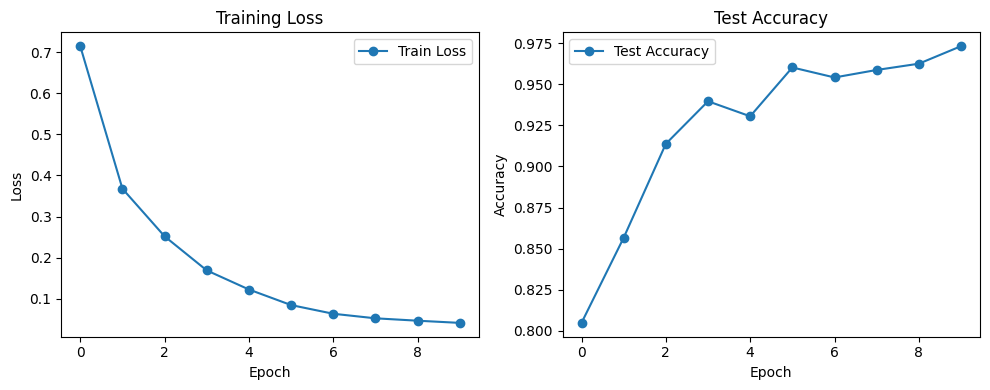

In [8]:
plt.figure(figsize=(10, 4))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

# Plot test accuracy
plt.subplot(1, 2, 2)
plt.plot(test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Test Accuracy')
plt.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()

## Classification Report and Confusion Matrix

Classification Report:

              precision    recall  f1-score   support

      glioma     0.9542    0.9733    0.9637       300
  meningioma     0.9722    0.9150    0.9428       306
     notumor     0.9878    0.9975    0.9926       405
   pituitary     0.9740    1.0000    0.9868       300

    accuracy                         0.9733      1311
   macro avg     0.9721    0.9715    0.9715      1311
weighted avg     0.9733    0.9733    0.9730      1311



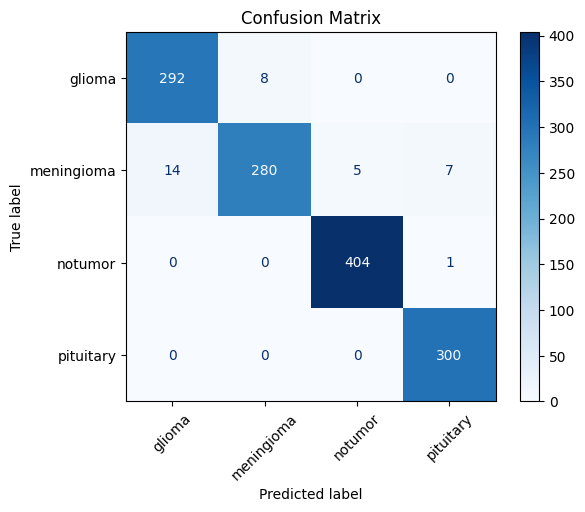

In [9]:
# Get predictions and true labels
preds, labels = get_predictions(model, test_loader, device)

# Classification Report
report = classification_report(labels, preds, target_names=class_names, digits=4)
print("Classification Report:\n")
print(report)

# Confusion Matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()